# 世界能源消耗資料分析：全球能源轉型趨勢與台灣能源結構挑戰

本 notebook 對應期末專題任務一到四：

1. 讀取與分析資料
2. 資料前處理
3. 產出圖表
4. 計算關鍵數字並輸出 `outputs/key_results.md`

注意：期末簡報內容、口頭報告講稿、PowerPoint 產出不放在此 notebook 程式碼內。

## 0. 建立輸出資料夾與匯入套件

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path("World Energy Consumption.csv")
OUT = Path("outputs")
FIG = OUT / "figures"
OUT.mkdir(exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

COUNTRIES = ["World", "Taiwan", "Germany", "China", "Japan", "United States", "India"]
COMPARE_ORDER = ["Germany", "China", "World", "Japan", "United States", "India", "Taiwan"]

NEEDED_COLS = [
    "country",
    "year",
    "population",
    "gdp",
    "primary_energy_consumption",
    "energy_per_capita",
    "fossil_share_energy",
    "renewables_share_energy",
    "low_carbon_share_energy",
    "coal_share_energy",
    "oil_share_energy",
    "gas_share_energy",
    "greenhouse_gas_emissions",
    "carbon_intensity_elec",
]

sns.set_theme(style="whitegrid", font="DejaVu Sans")

## 一、讀取與分析資料

In [8]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Year range: {df['year'].min()}-{df['year'].max()}")
print(f"Countries and regions: {df['country'].nunique():,}")

Rows: 22,012
Columns: 129
Year range: 1900-2022
Countries and regions: 306


In [9]:
print("Column names and data types:")
display(df.dtypes.reset_index().rename(columns={"index": "column", 0: "dtype"}))

Column names and data types:


,column,dtype
0,country,object
1,year,int64
2,iso_code,object
3,population,float64
4,gdp,float64
...,...,...
124,wind_elec_per_capita,float64
125,wind_electricity,float64
126,wind_energy_per_capita,float64
127,wind_share_elec,float64


In [10]:
missing_ratio_all = df.isna().mean().mul(100).sort_values(ascending=False)
display(missing_ratio_all.reset_index().rename(columns={"index": "column", 0: "missing_percent"}))

,column,missing_percent
0,biofuel_cons_change_pct,92.063420
1,solar_cons_change_pct,90.350718
2,biofuel_cons_per_capita,89.542068
3,wind_cons_change_pct,89.037798
4,nuclear_cons_change_pct,88.792477
...,...,...
124,oil_prod_change_twh,22.097038
125,oil_production,20.929493
126,population,17.667636
127,country,0.000000


In [11]:
missing_needed = [c for c in NEEDED_COLS if c not in df.columns]
replacement_notes = []

if not missing_needed:
    replacement_notes.append("All requested research columns exist in the CSV; no substitute fields were used.")
else:
    # If a future copy of the dataset lacks a requested field, choose the nearest meaningful field.
    candidate_map = {
        "primary_energy_consumption": ["energy_consumption"],
        "renewables_share_energy": ["renewables_share_elec"],
        "fossil_share_energy": ["fossil_share_elec"],
        "low_carbon_share_energy": ["low_carbon_share_elec"],
        "greenhouse_gas_emissions": ["co2", "carbon_emissions"],
        "carbon_intensity_elec": ["carbon_intensity"],
    }
    for col in missing_needed:
        substitute = next((alt for alt in candidate_map.get(col, []) if alt in df.columns), None)
        replacement_notes.append(f"{col}: replaced by {substitute or 'no close substitute found'}")

selected_cols = [c for c in NEEDED_COLS if c in df.columns]
selected = df[selected_cols].copy()

print("Field availability / substitution notes:")
for note in replacement_notes:
    print("-", note)

print(f"Selected columns: {len(selected.columns)}")
display(selected.head())

Field availability / substitution notes:
- All requested research columns exist in the CSV; no substitute fields were used.
Selected columns: 14


,country,year,population,gdp,primary_energy_consumption,energy_per_capita,fossil_share_energy,renewables_share_energy,low_carbon_share_energy,coal_share_energy,oil_share_energy,gas_share_energy,greenhouse_gas_emissions,carbon_intensity_elec
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,184.41,500.231
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,198.34,499.358
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,213.80,505.652
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,229.70,513.698
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,252.61,520.910


## 二、資料前處理

In [12]:
# 主要分析期間與比較對象
data_2000_2022 = selected[selected["year"].between(2000, 2022)].copy()
country_compare = data_2000_2022[data_2000_2022["country"].isin(COUNTRIES)].copy()

# 不同分析任務使用的乾淨資料
world_long = selected[(selected["country"] == "World") & (selected["year"].between(1900, 2022))].copy()
cross_2022 = selected[selected["year"] == 2022].copy()
taiwan_forecast_df = selected[
    (selected["country"] == "Taiwan") & (selected["year"].between(2000, 2022))
].copy()

print(f"Global long-term trend data: {world_long.shape}")
print(f"Country comparison data: {country_compare.shape}")
print(f"2022 cross-section data: {cross_2022.shape}")
print(f"Taiwan forecast data: {taiwan_forecast_df.shape}")

Global long-term trend data: (123, 14)
Country comparison data: (161, 14)
2022 cross-section data: (146, 14)
Taiwan forecast data: (23, 14)


In [13]:
print("Country comparison year coverage:")
display(country_compare.groupby("country")["year"].agg(["min", "max", "count"]))

print("Selected-column missing value ratios:")
selected_missing_ratio = selected.isna().mean().mul(100).sort_values(ascending=False)
display(selected_missing_ratio.reset_index().rename(columns={"index": "column", 0: "missing_percent"}))

Country comparison year coverage:


,min,max,count
country,,,
China,2000,2022,23
Germany,2000,2022,23
India,2000,2022,23
Japan,2000,2022,23
Taiwan,2000,2022,23
United States,2000,2022,23
World,2000,2022,23


Selected-column missing value ratios:


,column,missing_percent
0,gas_share_energy,78.252771
1,oil_share_energy,78.252771
2,coal_share_energy,78.252771
3,low_carbon_share_energy,78.252771
4,renewables_share_energy,78.252771
5,fossil_share_energy,78.252771
6,carbon_intensity_elec,76.535526
7,greenhouse_gas_emissions,75.894966
8,energy_per_capita,51.835363
9,gdp,49.513902


## 三、產出圖表

In [14]:
def savefig(filename):
    plt.tight_layout()
    plt.savefig(FIG / filename, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

def fmt(x, digits=2, suffix=""):
    if pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}{suffix}"

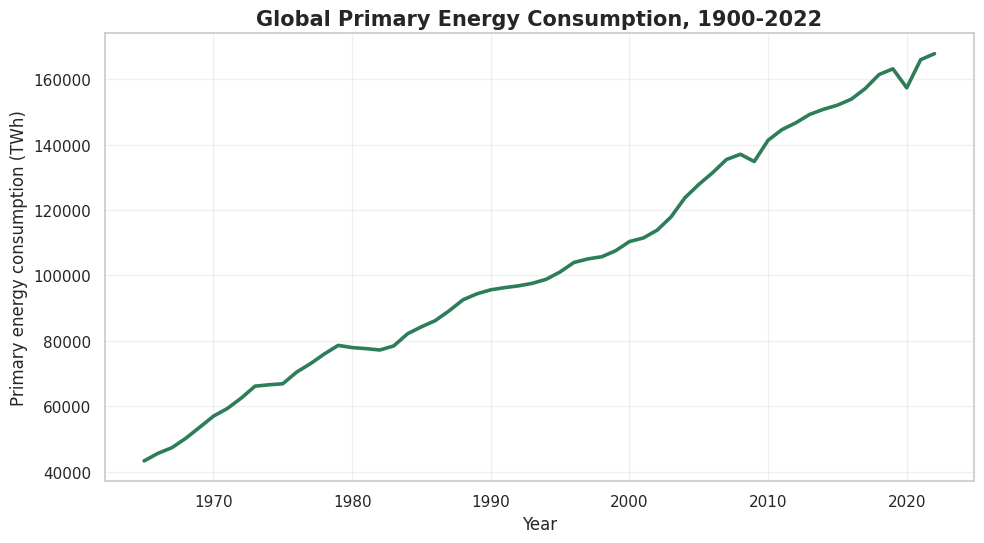

In [15]:
plt.figure(figsize=(10, 5.6))
plt.plot(world_long["year"], world_long["primary_energy_consumption"], color="#2E7D59", linewidth=2.6)
plt.title("Global Primary Energy Consumption, 1900-2022", fontsize=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("Primary energy consumption (TWh)")
plt.grid(True, alpha=0.28)
savefig("fig01_global_primary_energy_trend.png")

In [ ]:
structure_cols = [
    "coal_consumption",
    "oil_consumption",
    "gas_consumption",
    "renewables_consumption",
    "nuclear_consumption",
]
structure_labels = ["Coal", "Oil", "Gas", "Renewables", "Nuclear"]
structure = df[
    (df["country"] == "World") & (df["year"].between(1900, 2022))
][["year"] + structure_cols].dropna(how="all", subset=structure_cols)

plt.figure(figsize=(10, 5.6))
plt.stackplot(
    structure["year"],
    [structure[c].fillna(0) for c in structure_cols],
    labels=structure_labels,
    colors=["#4A4A4A", "#8E6C48", "#B7793C", "#4C9F70", "#7AA6C2"],
    alpha=0.92,
)
plt.title("Global Energy Structure by Source, 1900-2022", fontsize=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("Energy consumption (TWh)")
plt.legend(loc="upper left", ncol=3, frameon=True)
plt.grid(True, alpha=0.2)
savefig("fig02_global_energy_structure.png")

In [ ]:
world_2000_2022 = country_compare[country_compare["country"] == "World"]

plt.figure(figsize=(10, 5.6))
plt.plot(
    world_2000_2022["year"],
    world_2000_2022["renewables_share_energy"],
    color="#2E7D59",
    marker="o",
    linewidth=2.4,
)
plt.title("World Renewables Share of Primary Energy, 2000-2022", fontsize=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("Renewables share of energy (%)")
plt.grid(True, alpha=0.28)
savefig("fig03_world_renewables_share_trend.png")

In [ ]:
plt.figure(figsize=(10, 5.6))
for country, color in [("Taiwan", "#C75B4B"), ("World", "#2E7D59")]:
    d = country_compare[country_compare["country"] == country]
    plt.plot(
        d["year"],
        d["renewables_share_energy"],
        marker="o",
        linewidth=2.4,
        label=country,
        color=color,
    )
plt.title("Renewables Share: Taiwan vs World, 2000-2022", fontsize=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("Renewables share of energy (%)")
plt.legend()
plt.grid(True, alpha=0.28)
savefig("fig04_taiwan_vs_world_renewables.png")

In [ ]:
comp_2022 = cross_2022[cross_2022["country"].isin(COMPARE_ORDER)].copy()
ren_2022 = comp_2022[["country", "renewables_share_energy"]].dropna().sort_values(
    "renewables_share_energy", ascending=True
)

plt.figure(figsize=(10, 5.6))
bars = plt.barh(ren_2022["country"], ren_2022["renewables_share_energy"], color="#2E7D59")
plt.title("Renewables Share by Country, 2022", fontsize=15, weight="bold")
plt.xlabel("Renewables share of energy (%)")
plt.ylabel("Country")
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.35, bar.get_y() + bar.get_height() / 2, f"{width:.1f}%", va="center", fontsize=10)
plt.xlim(0, max(ren_2022["renewables_share_energy"]) * 1.18)
savefig("fig05_renewables_share_2022_country_comparison.png")

In [ ]:
plt.figure(figsize=(10, 5.6))
for country, color in [("Taiwan", "#C75B4B"), ("World", "#2E7D59")]:
    d = country_compare[country_compare["country"] == country]
    plt.plot(
        d["year"],
        d["fossil_share_energy"],
        marker="o",
        linewidth=2.4,
        label=country,
        color=color,
    )
plt.title("Fossil Fuel Share: Taiwan vs World, 2000-2022", fontsize=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("Fossil fuel share of energy (%)")
plt.legend()
plt.grid(True, alpha=0.28)
savefig("fig06_taiwan_vs_world_fossil_share.png")

In [ ]:
ci_2022 = comp_2022[["country", "carbon_intensity_elec"]].dropna().sort_values(
    "carbon_intensity_elec", ascending=True
)

plt.figure(figsize=(10, 5.6))
bars = plt.barh(ci_2022["country"], ci_2022["carbon_intensity_elec"], color="#6B8F71")
plt.title("Carbon Intensity of Electricity by Country, 2022", fontsize=15, weight="bold")
plt.xlabel("Carbon intensity of electricity (gCO2/kWh)")
plt.ylabel("Country")
for bar in bars:
    width = bar.get_width()
    plt.text(width + 8, bar.get_y() + bar.get_height() / 2, f"{width:.0f}", va="center", fontsize=10)
plt.xlim(0, max(ci_2022["carbon_intensity_elec"]) * 1.18)
savefig("fig07_carbon_intensity_2022_country_comparison.png")

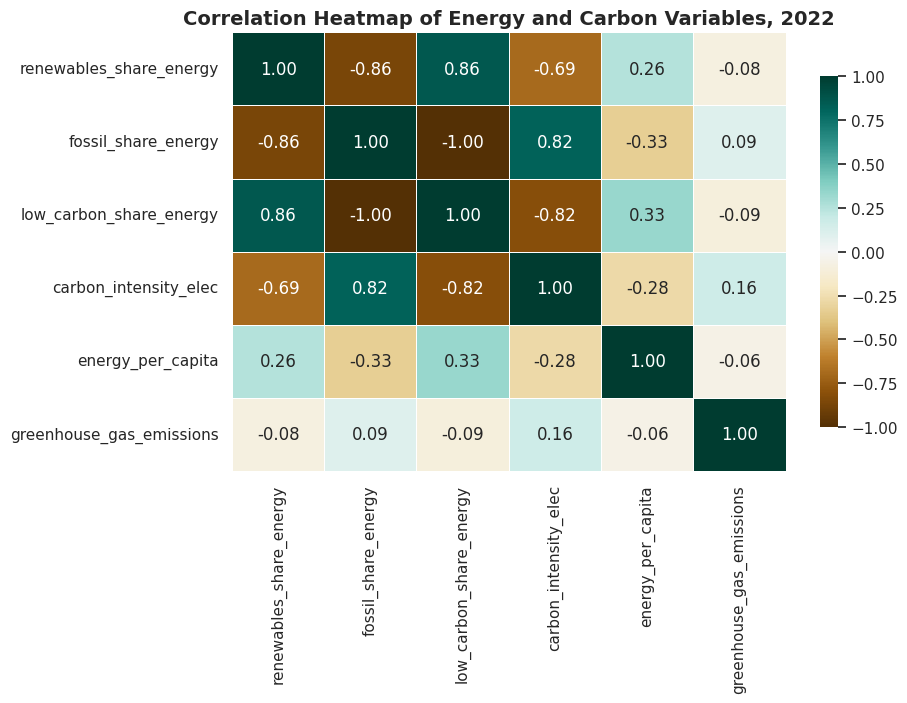

重點相關係數：
再生能源占比 vs 化石燃料占比: r = -0.86
低碳能源占比 vs 發電碳強度: r = -0.82
化石燃料占比 vs 發電碳強度: r = 0.82
再生能源占比 vs 發電碳強度: r = -0.69


In [18]:
corr_vars = [
    "renewables_share_energy",
    "fossil_share_energy",
    "low_carbon_share_energy",
    "carbon_intensity_elec",
    "energy_per_capita",
    "greenhouse_gas_emissions",
]

corr_df = cross_2022[corr_vars].dropna()
corr = corr_df.corr()

plt.figure(figsize=(9.5, 7.2))
sns.heatmap(
    corr,
    annot=True,
    cmap="BrBG",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap of Energy and Carbon Variables, 2022", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig("fig08_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# 印出簡報可用的重點相關係數
print("重點相關係數：")
print(f"再生能源占比 vs 化石燃料占比: r = {corr.loc['renewables_share_energy', 'fossil_share_energy']:.2f}")
print(f"低碳能源占比 vs 發電碳強度: r = {corr.loc['low_carbon_share_energy', 'carbon_intensity_elec']:.2f}")
print(f"化石燃料占比 vs 發電碳強度: r = {corr.loc['fossil_share_energy', 'carbon_intensity_elec']:.2f}")
print(f"再生能源占比 vs 發電碳強度: r = {corr.loc['renewables_share_energy', 'carbon_intensity_elec']:.2f}")

Cluster profile:
         renewables_share_energy  fossil_share_energy  \
cluster                                                 
0                           9.88                89.07   
1                          45.25                46.49   
2                          21.13                71.89   
3                           9.98                83.48   

         low_carbon_share_energy  carbon_intensity_elec  energy_per_capita  
cluster                                                                     
0                          10.93                 514.17           21616.15  
1                          53.51                  94.85           55720.90  
2                          28.11                 247.46           26389.90  
3                          16.52                 380.30           58688.32  

Representative countries:
cluster
0     Thailand, North Macedonia, Mexico, Poland, Egypt
1    Finland, New Zealand, Switzerland, Denmark, Br...
2    United Kingdom, Spain, Croat

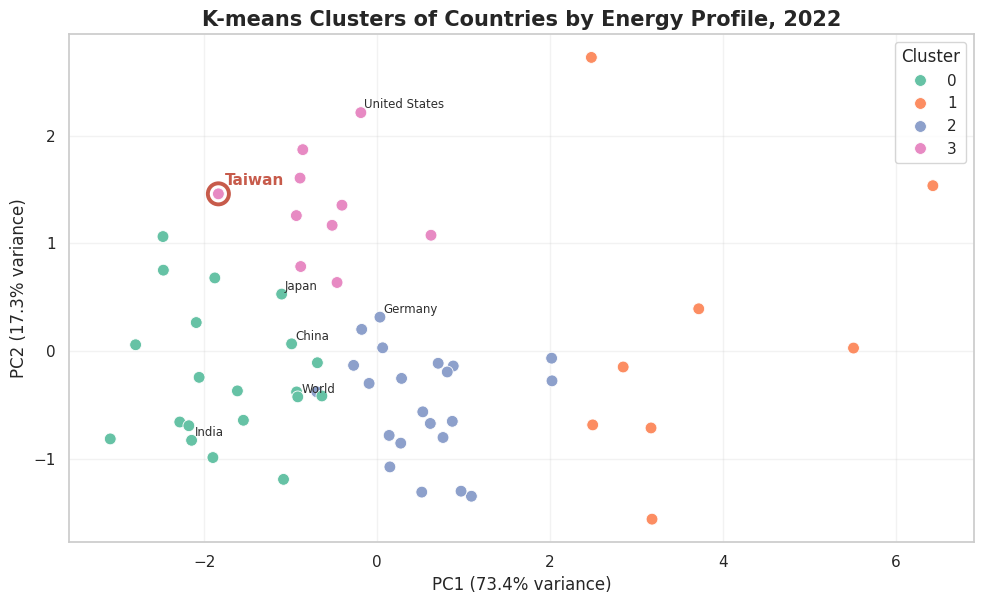

K used: 4
Taiwan cluster: 3
Complete rows used for K-means: 60


In [17]:
cluster_vars = [
    "renewables_share_energy",
    "fossil_share_energy",
    "low_carbon_share_energy",
    "carbon_intensity_elec",
    "energy_per_capita",
]

cluster_df = cross_2022[["country"] + cluster_vars].dropna().copy()
k = 4 if len(cluster_df) >= 4 else max(2, len(cluster_df))

X = StandardScaler().fit_transform(cluster_df[cluster_vars])
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
cluster_df["cluster"] = kmeans.fit_predict(X)

# 各 cluster 的平均能源特徵
cluster_profile = cluster_df.groupby("cluster")[cluster_vars].mean().round(2)

print("Cluster profile:")
print(cluster_profile)

# 找出每個國家到自己 cluster 中心的距離
cluster_df["distance_to_center"] = np.linalg.norm(
    X - kmeans.cluster_centers_[cluster_df["cluster"]],
    axis=1
)

# 每群取距離中心最近的前 5 個國家，作為代表國家
representative_countries = (
    cluster_df.sort_values(["cluster", "distance_to_center"])
    .groupby("cluster")
    .head(5)
    .groupby("cluster")["country"]
    .apply(lambda x: ", ".join(x))
)

print("\nRepresentative countries:")
print(representative_countries)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X)
cluster_df["PC1"] = pcs[:, 0]
cluster_df["PC2"] = pcs[:, 1]

taiwan_cluster = int(cluster_df.loc[cluster_df["country"] == "Taiwan", "cluster"].iloc[0])

plt.figure(figsize=(10, 6.2))
palette = sns.color_palette("Set2", n_colors=k)
sns.scatterplot(
    data=cluster_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=palette,
    s=72,
    edgecolor="white",
    linewidth=0.6,
)

tw = cluster_df[cluster_df["country"] == "Taiwan"].iloc[0]
plt.scatter([tw["PC1"]], [tw["PC2"]], s=230, facecolors="none", edgecolors="#C75B4B", linewidths=2.8)
plt.text(tw["PC1"] + 0.08, tw["PC2"] + 0.08, "Taiwan", color="#C75B4B", weight="bold", fontsize=11)

for name in ["World", "Germany", "China", "Japan", "United States", "India"]:
    d = cluster_df[cluster_df["country"] == name]
    if not d.empty:
        row = d.iloc[0]
        plt.text(row["PC1"] + 0.04, row["PC2"] + 0.04, name, fontsize=8.5, color="#2E2E2E")

plt.title("K-means Clusters of Countries by Energy Profile, 2022", fontsize=15, weight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="Cluster", loc="best")
plt.grid(True, alpha=0.25)
savefig("fig09_kmeans_clusters.png")

print(f"K used: {k}")
print(f"Taiwan cluster: {taiwan_cluster}")
print(f"Complete rows used for K-means: {len(cluster_df)}")

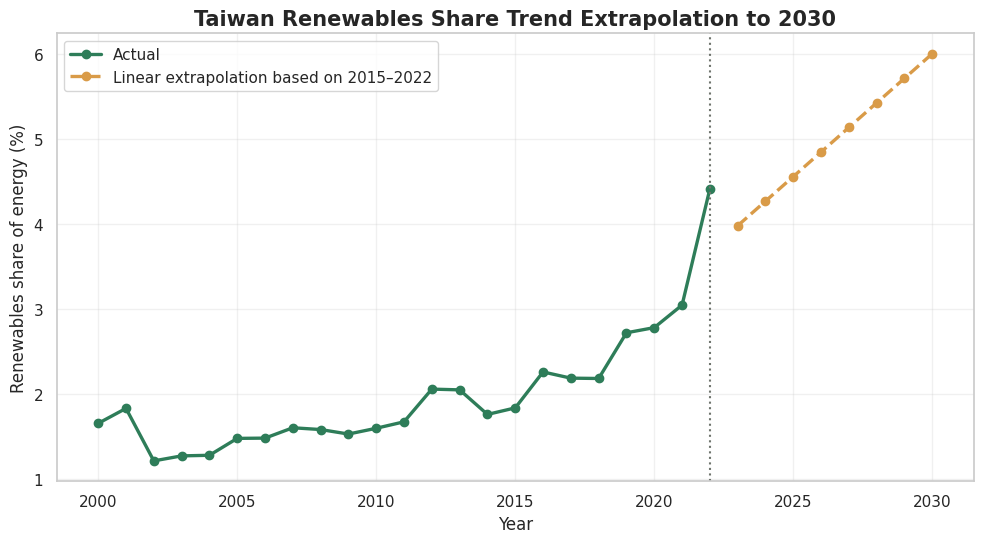

Taiwan 2030 renewables_share_energy trend extrapolation: 6.002%


In [13]:
tw_model_df = taiwan_forecast_df[
    ["year", "renewables_share_energy"]
].dropna().copy()

# 改用近年資料建立模型
tw_recent_df = tw_model_df[tw_model_df["year"] >= 2015].copy()

lr = LinearRegression()
lr.fit(tw_recent_df[["year"]], tw_recent_df["renewables_share_energy"])

future_years = np.arange(2023, 2031)
future_pred = lr.predict(pd.DataFrame({"year": future_years}))
forecast_2030 = float(future_pred[-1])

plt.figure(figsize=(10, 5.6))

# 畫出完整歷史資料
plt.plot(
    tw_model_df["year"],
    tw_model_df["renewables_share_energy"],
    marker="o",
    linewidth=2.4,
    color="#2E7D59",
    label="Actual",
)

# 畫出近年模型外推結果
plt.plot(
    future_years,
    future_pred,
    marker="o",
    linewidth=2.4,
    linestyle="--",
    color="#D99B48",
    label="Linear extrapolation based on 2015–2022",
)

plt.axvline(2022, color="#6F746D", linestyle=":", linewidth=1.5)
plt.title("Taiwan Renewables Share Trend Extrapolation to 2030", fontsize=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("Renewables share of energy (%)")
plt.legend()
plt.grid(True, alpha=0.28)

savefig("fig10_taiwan_renewables_forecast_2030.png")

print(f"Taiwan 2030 renewables_share_energy trend extrapolation: {forecast_2030:.3f}%")

## 四、計算關鍵數字並輸出 `outputs/key_results.md`

In [ ]:
def value_at(country, year, column):
    row = df[(df["country"] == country) & (df["year"] == year)]
    if row.empty:
        return np.nan
    return row.iloc[0][column]

world_2000_ren = value_at("World", 2000, "renewables_share_energy")
world_2022_ren = value_at("World", 2022, "renewables_share_energy")
taiwan_2000_ren = value_at("Taiwan", 2000, "renewables_share_energy")
taiwan_2022_ren = value_at("Taiwan", 2022, "renewables_share_energy")

taiwan_2022_fossil = value_at("Taiwan", 2022, "fossil_share_energy")
world_2022_fossil = value_at("World", 2022, "fossil_share_energy")
taiwan_2022_ci = value_at("Taiwan", 2022, "carbon_intensity_elec")
world_2022_ci = value_at("World", 2022, "carbon_intensity_elec")

country_renewables_2022 = (
    cross_2022[cross_2022["country"].isin(COMPARE_ORDER)]
    .set_index("country")
    .loc[COMPARE_ORDER, "renewables_share_energy"]
)

key_table = pd.DataFrame(
    {
        "item": [
            "World 2000 renewables_share_energy",
            "World 2022 renewables_share_energy",
            "Taiwan 2000 renewables_share_energy",
            "Taiwan 2022 renewables_share_energy",
            "Taiwan 2022 fossil_share_energy",
            "World 2022 fossil_share_energy",
            "Taiwan 2022 carbon_intensity_elec",
            "World 2022 carbon_intensity_elec",
            "Taiwan K-means cluster",
            "Taiwan 2030 renewables_share_energy trend extrapolation",
        ],
        "value": [
            f"{world_2000_ren:.3f}%",
            f"{world_2022_ren:.3f}%",
            f"{taiwan_2000_ren:.3f}%",
            f"{taiwan_2022_ren:.3f}%",
            f"{taiwan_2022_fossil:.3f}%",
            f"{world_2022_fossil:.3f}%",
            f"{taiwan_2022_ci:.3f} gCO2/kWh",
            f"{world_2022_ci:.3f} gCO2/kWh",
            str(taiwan_cluster),
            f"{forecast_2030:.3f}%",
        ],
    }
)

display(key_table)
display(country_renewables_2022.reset_index().rename(columns={"renewables_share_energy": "renewables_share_energy_2022"}))

In [ ]:
selected_dtype = selected.dtypes.astype(str)
selected_missing = selected.isna().mean().mul(100).sort_values(ascending=False)

key_results_md = f'''# Key Results

## Data Check

- Dataset: `World Energy Consumption.csv`
- Rows: {df.shape[0]:,}
- Columns: {df.shape[1]:,}
- Year range: {int(df["year"].min())}-{int(df["year"].max())}
- Countries and regions: {df["country"].nunique():,}
- Selected research columns: {len(selected.columns)}

## Field Availability

{chr(10).join(["- " + note for note in replacement_notes])}

## Selected Column Types

| Column | Type |
|---|---|
{chr(10).join([f"| {col} | {selected_dtype[col]} |" for col in selected.columns])}

## Missing Value Ratio in Selected Columns

| Column | Missing % |
|---|---:|
{chr(10).join([f"| {col} | {selected_missing[col]:.2f}% |" for col in selected_missing.index])}

## Clean Analysis Datasets

- Global long-term trend: World, 1900-2022, {len(world_long):,} rows.
- Country comparison: World, Taiwan, Germany, China, Japan, United States, India, 2000-2022, {len(country_compare):,} rows.
- 2022 cross-section: all countries and regions in 2022, {len(cross_2022):,} rows.
- Taiwan trend extrapolation: Taiwan, 2000-2022, {len(taiwan_forecast_df):,} rows.
- K-means: removed missing values before clustering; {len(cluster_df):,} complete 2022 rows used. Variables were standardized with `StandardScaler`. K = {k}.

## Required Numerical Results

| Item | Value |
|---|---:|
| World 2000 renewables_share_energy | {world_2000_ren:.3f}% |
| World 2022 renewables_share_energy | {world_2022_ren:.3f}% |
| Taiwan 2000 renewables_share_energy | {taiwan_2000_ren:.3f}% |
| Taiwan 2022 renewables_share_energy | {taiwan_2022_ren:.3f}% |
| Taiwan 2022 fossil_share_energy | {taiwan_2022_fossil:.3f}% |
| World 2022 fossil_share_energy | {world_2022_fossil:.3f}% |
| Taiwan 2022 carbon_intensity_elec | {taiwan_2022_ci:.3f} gCO2/kWh |
| World 2022 carbon_intensity_elec | {world_2022_ci:.3f} gCO2/kWh |
| Taiwan K-means cluster | {taiwan_cluster} |
| Taiwan 2030 renewables_share_energy trend extrapolation | {forecast_2030:.3f}% |

## 2022 Renewables Share by Main Comparison Group

| Country/Region | renewables_share_energy |
|---|---:|
{chr(10).join([f"| {country} | {value:.3f}% |" for country, value in country_renewables_2022.items()])}

## Notes for Interpretation

- The 2030 value is a simple linear trend extrapolation based on Taiwan's 2000-2022 renewables share. It should be interpreted as a trend reference, not a precise forecast.
- K-means cluster labels are numeric model labels. The meaning should be interpreted through the variables and relative positions in the PCA plot.
- Missing values were not imputed. Each analysis excludes rows with missing values only for the variables needed in that analysis.
'''

key_results_md = "\n".join(line.strip() for line in key_results_md.splitlines())
(OUT / "key_results.md").write_text(key_results_md, encoding="utf-8")
print("Saved:", OUT / "key_results.md")

In [ ]:
expected_figures = [
    "fig01_global_primary_energy_trend.png",
    "fig02_global_energy_structure.png",
    "fig03_world_renewables_share_trend.png",
    "fig04_taiwan_vs_world_renewables.png",
    "fig05_renewables_share_2022_country_comparison.png",
    "fig06_taiwan_vs_world_fossil_share.png",
    "fig07_carbon_intensity_2022_country_comparison.png",
    "fig08_correlation_heatmap.png",
    "fig09_kmeans_clusters.png",
    "fig10_taiwan_renewables_forecast_2030.png",
]

for filename in expected_figures:
    path = FIG / filename
    print(("OK" if path.exists() and path.stat().st_size > 0 else "MISSING"), path)

key_path = OUT / "key_results.md"
print(("OK" if key_path.exists() and key_path.stat().st_size > 0 else "MISSING"), key_path)